In [1]:
import torch
import torch.nn as nn
import torchaudio
import torch.nn.functional as F
import torchaudio.transforms as T
from typing import List, Dict, Optional, Iterable, Tuple

import os, re, random
import numpy as np
import sklearn
import itertools
import time

import pickle
from tqdm.auto import tqdm
from IPython.display import clear_output
import IPython.display as ipd
import gc
import matplotlib.pyplot as plt
# import wandb

print(torch.__version__)
print(torchaudio.__version__)

import sys
# sys.path.append("/home/iblitvinov@vniia.int/projects/Voice-commands-recognition")

torch.cuda.empty_cache()
gc.collect()

/Users/litvan007/Voice-commands-recognition/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.0.1
2.0.2


0

In [2]:
data_path = '/Users/litvan007/Voice-commands-recognition/data/stock_data_last_export'
with open(os.path.join(data_path, 'train_data_base_audio.pickle'), 'rb') as fh:
    train_data_list = pickle.load(fh)

with open(os.path.join(data_path, 'valid_data_base_audio.pickle'), 'rb') as fh:
    valid_data_list = pickle.load(fh)

len(train_data_list), len(valid_data_list)

(29721, 544)

In [3]:
device = 'cpu'

random.seed(123456)
np.random.seed(123456)
torch.manual_seed(123456)

def create_plots(signal, feature_map, name_fig, sample_rate=16000, 
                            signal_plot_dir='signal_plots', 
                            spec_plot_dir='spec_plots', 
                            mfcc_plot_dir='mfcc_plots',
                            notebook_path='/home/iblitvinov@vniia.int/projects/Voice-commands-recognition/notebooks'):
    
    signal = signal.cpu().numpy()

    num_frames = signal.size
    time_axis = torch.arange(0, num_frames) / sample_rate
    plt.plot(time_axis, signal, linewidth=1)
    plt.xlabel('Time')
    plt.title('Signal')
    plt.grid()
    plt.savefig(os.path.join(notebook_path, signal_plot_dir, name_fig))
    plt.clf()

    plt.specgram(signal, Fs=sample_rate)
    plt.xlabel('Time')
    plt.title('Spectrogram')
    plt.savefig(os.path.join(notebook_path, spec_plot_dir, name_fig))
    plt.clf()

    plt.imshow(feature_map.cpu(), interpolation='nearest', origin='lower', aspect='auto')
    plt.xlabel('Frame')
    plt.title('MFCC')
    plt.savefig(os.path.join(notebook_path, mfcc_plot_dir, name_fig))
    plt.clf()
    
def plot_waveform(waveform, mfcc, sample_rate=16000, title="Waveform", xlim=None):
    waveform = waveform.cpu().numpy()

    num_frames = waveform.size
    time_axis = torch.arange(0, num_frames) / sample_rate

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
    ax1.plot(time_axis, waveform, linewidth=1)
    ax1.set_xlabel('Time')
    ax1.set_title('Signal')

    ax2.specgram(waveform, Fs=sample_rate)
    ax2.set_xlabel('Time')
    ax2.set_title('Spectrogram')

    ax3.imshow(mfcc.cpu(), interpolation='nearest', origin='lower', aspect='auto')
    ax3.set_xlabel('Frame')
    ax3.set_title('MFCC')

    plt.suptitle(title)
    plt.show()
    
    ax1.grid(True)
    if xlim:
        ax1.set_xlim(xlim)
        
    fig.suptitle(title)
    plt.show()

In [4]:
import gc

all_labels = [
 'Домой',
 'Двигаться',
 'Найти',
 'Опустить',
 'Остановиться',
 'Открыть', 
 'Поднять',
 'Сменить',
 'Сохранить',
 'Старт',
 'Стоп',   
 'Влево',
 'Вниз',   
 'Вправо',
 'Вверх',  
 'Загрузить',
 'Захватить',   
 'Закрыть'
 ]

token_to_idx = {x: idx for idx, x in enumerate(all_labels)}
all_labels, token_to_idx

class Sound_dataset_commands(torch.utils.data.Dataset):
    def __init__(self, rootdir, subset, transform=None):
        self.transform = transform
        self.rootdir = rootdir
        self.subset = subset
        self.n_subset = len(self.subset)
        self.token_to_idx = {x: idx for idx, x in enumerate(all_labels)}
        self.idx_to_token = {idx: x for idx, x in enumerate(all_labels)}

        self.preprocessed_dataset = self._preprocessing()
        torch.cuda.empty_cache()
        gc.collect()
        self.preprocessed_dataset = self.preprocessed_dataset

    def _preprocessing(self):
        dataset = []
        for sound in tqdm(self.subset):
            name, label = sound.values()
            signal, _ = torchaudio.load(os.path.join(self.rootdir, name))
            signal = signal[0]
            if self.transform:
                feature_map = self.transform(signal)
#               signal = self.transform.transforms[0](signal)
            idx_label = self.token_to_idx[label]
            dataset.append((feature_map.to(device), idx_label, signal.to(device)))
        
        return dataset

    def __getitem__(self, index):
        feature_map, idx_label, signal = self.preprocessed_dataset[index]
        name, label = self.subset[index].values()

        return feature_map, idx_label, signal, name, label

    def __len__(self):
        return len(self.subset)

In [5]:
# 30мс 10мс шаг
n_fft = 480
win_length = None
hop_length = 160
mfcc_transform = T.MFCC(
    sample_rate=16000,
    n_mfcc=32,
    melkwargs={
        "n_fft": n_fft,
        "n_mels": 64,
        "hop_length": hop_length
    },
)

transform = mfcc_transform
data_set = {
            'train': Sound_dataset_commands(rootdir=data_path, subset=train_data_list, transform=transform),
            'valid': Sound_dataset_commands(rootdir=data_path, subset=valid_data_list, transform=transform),
            # 'test': Sound_dataset_commands(rootdir=data_path, subset=test_subset, transform=transform)
        }
c = itertools.cycle(data_set['valid'])

100%|██████████| 544/544 [00:01<00:00, 404.78it/s]


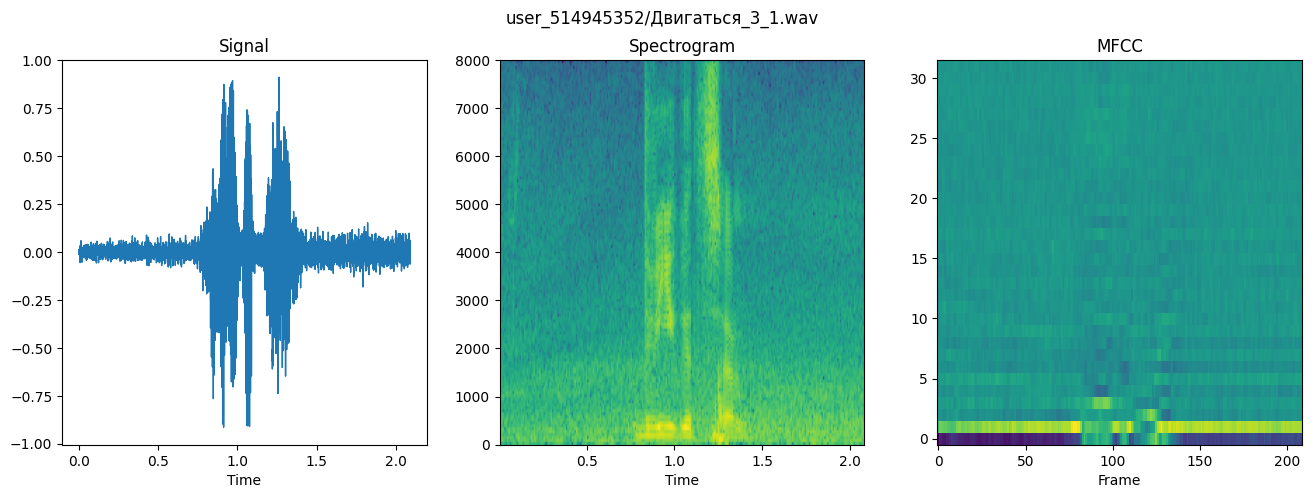

In [6]:
mfcc, label, signal, xname, label = next(c)
plot_waveform(signal, mfcc, sample_rate=16000, title=f'{xname}')
ipd.Audio(signal.cpu(), rate=16000)

In [7]:
import sys
sys.path.append('..')

from models.model import Speech_recognition_model
import yaml

# Сделать разные конфиги
params = None
with open("../configs/model_params_res.yaml", "r") as stream:
    try:
        params = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

In [8]:
params

{'Architecture': {'CNN_params': {'in_channels': 1,
   'out_channels': 64,
   'kernel_size': 5,
   'stride': 2,
   'padding': 2},
  'ResCNN_params': {'in_channels': 64,
   'out_channels': 64,
   'kernel_size': 5,
   'stride': 1,
   'dropout': 0.4564897206289136,
   'n_feats': 16,
   'padding': 2,
   'n_cnn_layers': 5},
  'Fully_connected_params': {'in_features': 1024, 'out_features': 512},
  'RNN_params': {'input_size': 512,
   'hidden_size': 512,
   'num_layers': 4,
   'bidirectional': True,
   'dropout': 0.3147392547906197,
   'rnn_type': 'lstm'},
  'Attention_params': {'feature_dim': 512, 'step_dim': 8},
  'Classifier_params': {'in_features': 512,
   'out_features': 512,
   'dropout': 0.48890324556429815,
   'n_class': 18}},
 'Settings': {'Optimizer_Scheduler': {'lr_rate': '5e-4',
   'weight_decay': 0.0005,
   'amsgrad': False,
   'max_lr': 0.07,
   'div_factor': 125,
   'max_norm': 1.4},
  'Other': {'epochs': 100, 'batch_size': 64}}}

In [9]:
def collate_fn(batch):
    X = torch.nn.utils.rnn.pad_sequence([sample[0].transpose(0, 1) for sample in batch], batch_first=True, padding_value=0).unsqueeze(1)
    y = torch.Tensor([sample[1] for sample in batch]).to(torch.long).to(device)

    signal = [sample[2] for sample in batch]
    name = [sample[3] for sample in batch]
    label = [sample[4] for sample in batch]

    return X, y, signal, name, label

batch_size = params['Settings']['Other']['batch_size']
epochs = params['Settings']['Other']['epochs']
max_norm = params['Settings']['Optimizer_Scheduler']['max_norm']
loaders = {
        # 'train': torch.utils.data.DataLoader(data_set['train'], batch_size=batch_size, shuffle=True, collate_fn=collate_fn),
        'valid': torch.utils.data.DataLoader(data_set['valid'], batch_size=batch_size, shuffle=True, collate_fn=collate_fn),
        # 'test': torch.utils.data.DataLoader(data_set['test'], batch_size=1, shuffle=False, collate_fn=collate_fn)
        }

In [10]:
from models.model import Speech_recognition_model

def create_model_utils(params, weight_decay, amsgrad, max_lr, div_factor, epochs, steps_per_epoch=225, tl=False, tl_type='freeze', tl_low_lr=1e-8, load_path=None):
    tr_loss = []
    cv_loss = []
    tr_acc = []
    cv_acc = []
    epoch = 0
    model = Speech_recognition_model(**params).to(device)
    criterion = torch.nn.CrossEntropyLoss(reduction='mean').to(device)

    optimizer = torch.optim.Adam(model.parameters(),
                                lr=max_lr/div_factor,
                                weight_decay=weight_decay,
                                amsgrad=amsgrad)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=max_lr,
                            steps_per_epoch=steps_per_epoch,
                            epochs=epochs, div_factor=div_factor)

    if tl:
        model.load_state_dict(torch.load('../../checkpoints/sub_model_asr_2.pth', map_location=device), strict=False)
        if tl_type == 'freeze':
            for param in list(model.parameters())[:28]: #28
                param.requires_grad = False

        elif tl_type == 'low_step':
            optimizer = torch.optim.Adam(params=[
                                            {"params": list(model.parameters())[28:]},
                                            {"params": list(model.parameters())[:28], "lr": tl_low_lr}
                                        ], lr=max_lr/div_factor, weight_decay=weight_decay, amsgrad=amsgrad)

        elif tl_type == 'non_freeze':
            pass

    if load_path is not None:
        checkpoint = torch.load(load_path, map_location=torch.device('cpu'))
        print( checkpoint.keys() )

        model.load_state_dict(checkpoint['state_dict'])
        optimizer.load_state_dict(checkpoint['optim_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_dict'])
        tr_loss = checkpoint['tr_loss']
        cv_loss = checkpoint['cv_loss']
        epoch = checkpoint['epoch']
        tr_acc = checkpoint['tr_accuracy']
        # cv_acc = checkpoint['cv_accuracy']
    
    return model, criterion, optimizer, scheduler, tr_loss, cv_loss, epoch, tr_acc, cv_acc

epochs = 1000
model, criterion, optimizer, scheduler, tr_loss, cv_loss, epoch, tr_acc, cv_acc = create_model_utils(params['Architecture'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['weight_decay'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['amsgrad'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['max_lr'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['div_factor'],
                                                                                                    epochs,
                                                                                                    tl=False, load_path='../epoch_38_loss_0.2248_best_last_model.pth.tar')

Not setting weights for type <class 'torch.nn.modules.dropout.Dropout'>
Not setting weights for type <class 'torch.nn.modules.dropout.Dropout'>
Not setting weights for type <class 'torch.nn.modules.normalization.LayerNorm'>
Not setting weights for type <class 'models.cnn.CNNLayerNorm'>
Not setting weights for type <class 'torch.nn.modules.normalization.LayerNorm'>
Not setting weights for type <class 'models.cnn.CNNLayerNorm'>
Not setting weights for type <class 'models.cnn.ResidualCNN'>
Not setting weights for type <class 'torch.nn.modules.dropout.Dropout'>
Not setting weights for type <class 'torch.nn.modules.dropout.Dropout'>
Not setting weights for type <class 'torch.nn.modules.normalization.LayerNorm'>
Not setting weights for type <class 'models.cnn.CNNLayerNorm'>
Not setting weights for type <class 'torch.nn.modules.normalization.LayerNorm'>
Not setting weights for type <class 'models.cnn.CNNLayerNorm'>
Not setting weights for type <class 'models.cnn.ResidualCNN'>
Not setting weig

In [11]:
model.eval()
data_set['valid'][0]

(tensor([[-1.3583e+02, -1.0624e+02, -1.1066e+02,  ..., -7.4315e+01,
          -7.9203e+01, -8.0803e+01],
         [ 4.0505e+01,  6.6397e+01,  6.7783e+01,  ...,  8.7386e+01,
           8.8108e+01,  8.8319e+01],
         [-2.0148e+00,  4.9141e+00, -1.6536e+00,  ..., -3.1547e+00,
          -5.9801e+00, -9.3003e-02],
         ...,
         [ 3.1254e+00,  5.7321e-01,  2.4744e+00,  ...,  2.2673e+00,
           3.1486e+00, -3.3435e+00],
         [-2.0702e+00,  2.2202e+00,  1.7129e+00,  ...,  2.4327e+00,
           3.3354e-01, -1.9567e-01],
         [-3.9388e+00, -1.2635e+00,  4.5246e-01,  ..., -2.2192e+00,
          -2.0477e+00,  5.7721e-01]]),
 1,
 tensor([ 0.0000,  0.0000,  0.0000,  ..., -0.0276, -0.0186, -0.0104]),
 'user_514945352/Двигаться_3_1.wav',
 'Двигаться')

In [12]:
new_labels = {i : el for i, el in enumerate(all_labels)}
freq_new_labels = {i : {el: 0 for el in all_labels} for i in range(len(all_labels))}
new_labels, freq_new_labels

({0: 'Домой',
  1: 'Двигаться',
  2: 'Найти',
  3: 'Опустить',
  4: 'Остановиться',
  5: 'Открыть',
  6: 'Поднять',
  7: 'Сменить',
  8: 'Сохранить',
  9: 'Старт',
  10: 'Стоп',
  11: 'Влево',
  12: 'Вниз',
  13: 'Вправо',
  14: 'Вверх',
  15: 'Загрузить',
  16: 'Захватить',
  17: 'Закрыть'},
 {0: {'Домой': 0,
   'Двигаться': 0,
   'Найти': 0,
   'Опустить': 0,
   'Остановиться': 0,
   'Открыть': 0,
   'Поднять': 0,
   'Сменить': 0,
   'Сохранить': 0,
   'Старт': 0,
   'Стоп': 0,
   'Влево': 0,
   'Вниз': 0,
   'Вправо': 0,
   'Вверх': 0,
   'Загрузить': 0,
   'Захватить': 0,
   'Закрыть': 0},
  1: {'Домой': 0,
   'Двигаться': 0,
   'Найти': 0,
   'Опустить': 0,
   'Остановиться': 0,
   'Открыть': 0,
   'Поднять': 0,
   'Сменить': 0,
   'Сохранить': 0,
   'Старт': 0,
   'Стоп': 0,
   'Влево': 0,
   'Вниз': 0,
   'Вправо': 0,
   'Вверх': 0,
   'Загрузить': 0,
   'Захватить': 0,
   'Закрыть': 0},
  2: {'Домой': 0,
   'Двигаться': 0,
   'Найти': 0,
   'Опустить': 0,
   'Остановиться': 0,


In [13]:
# mfcc, label, signal, xname, label = next(c)
# mfcc, label, signal, xname, label = data_set['valid'][10]

for batch in data_set['valid']:
    mfcc, label, signal, xname, label = batch
    input = mfcc.transpose(0, 1)              # Меняем оси
    input = input.unsqueeze(0).unsqueeze(0)    # -> [1, 1, time, freq]
    outputs = model(input)

    preds = torch.argmax(F.softmax(outputs, dim=1), dim=1).item()

    if label != all_labels[preds]:
        new_labels[preds] = label
        freq_new_labels[preds][label] += 1

# print( label )
# print( preds, all_labels[preds] )

# plot_waveform(signal, mfcc, sample_rate=16000, title=f'{xname}')
# ipd.Audio(signal.cpu(), rate=16000)

In [14]:
freq_new_labels

{0: {'Домой': 0,
  'Двигаться': 0,
  'Найти': 0,
  'Опустить': 36,
  'Остановиться': 0,
  'Открыть': 0,
  'Поднять': 0,
  'Сменить': 0,
  'Сохранить': 0,
  'Старт': 1,
  'Стоп': 0,
  'Влево': 0,
  'Вниз': 0,
  'Вправо': 0,
  'Вверх': 0,
  'Загрузить': 0,
  'Захватить': 0,
  'Закрыть': 0},
 1: {'Домой': 0,
  'Двигаться': 0,
  'Найти': 0,
  'Опустить': 0,
  'Остановиться': 0,
  'Открыть': 0,
  'Поднять': 0,
  'Сменить': 1,
  'Сохранить': 0,
  'Старт': 1,
  'Стоп': 0,
  'Влево': 0,
  'Вниз': 1,
  'Вправо': 0,
  'Вверх': 0,
  'Загрузить': 0,
  'Захватить': 0,
  'Закрыть': 0},
 2: {'Домой': 0,
  'Двигаться': 0,
  'Найти': 0,
  'Опустить': 0,
  'Остановиться': 1,
  'Открыть': 0,
  'Поднять': 0,
  'Сменить': 0,
  'Сохранить': 27,
  'Старт': 0,
  'Стоп': 0,
  'Влево': 0,
  'Вниз': 0,
  'Вправо': 0,
  'Вверх': 0,
  'Загрузить': 0,
  'Захватить': 0,
  'Закрыть': 0},
 3: {'Домой': 0,
  'Двигаться': 0,
  'Найти': 1,
  'Опустить': 0,
  'Остановиться': 0,
  'Открыть': 0,
  'Поднять': 1,
  'Сменить':

In [15]:
final_labels = {}
for idx, stats in freq_new_labels.items():
    max_key = max(stats, key=stats.get)
    if stats[max_key] > 5:
        final_labels[idx] = max_key
    else:
        final_labels[idx] = all_labels[idx]

In [16]:
freq_new_labels

{0: {'Домой': 0,
  'Двигаться': 0,
  'Найти': 0,
  'Опустить': 36,
  'Остановиться': 0,
  'Открыть': 0,
  'Поднять': 0,
  'Сменить': 0,
  'Сохранить': 0,
  'Старт': 1,
  'Стоп': 0,
  'Влево': 0,
  'Вниз': 0,
  'Вправо': 0,
  'Вверх': 0,
  'Загрузить': 0,
  'Захватить': 0,
  'Закрыть': 0},
 1: {'Домой': 0,
  'Двигаться': 0,
  'Найти': 0,
  'Опустить': 0,
  'Остановиться': 0,
  'Открыть': 0,
  'Поднять': 0,
  'Сменить': 1,
  'Сохранить': 0,
  'Старт': 1,
  'Стоп': 0,
  'Влево': 0,
  'Вниз': 1,
  'Вправо': 0,
  'Вверх': 0,
  'Загрузить': 0,
  'Захватить': 0,
  'Закрыть': 0},
 2: {'Домой': 0,
  'Двигаться': 0,
  'Найти': 0,
  'Опустить': 0,
  'Остановиться': 1,
  'Открыть': 0,
  'Поднять': 0,
  'Сменить': 0,
  'Сохранить': 27,
  'Старт': 0,
  'Стоп': 0,
  'Влево': 0,
  'Вниз': 0,
  'Вправо': 0,
  'Вверх': 0,
  'Загрузить': 0,
  'Захватить': 0,
  'Закрыть': 0},
 3: {'Домой': 0,
  'Двигаться': 0,
  'Найти': 1,
  'Опустить': 0,
  'Остановиться': 0,
  'Открыть': 0,
  'Поднять': 1,
  'Сменить':

In [17]:
final_labels

{0: 'Опустить',
 1: 'Двигаться',
 2: 'Сохранить',
 3: 'Вниз',
 4: 'Старт',
 5: 'Открыть',
 6: 'Сменить',
 7: 'Вверх',
 8: 'Захватить',
 9: 'Влево',
 10: 'Поднять',
 11: 'Закрыть',
 12: 'Остановиться',
 13: 'Загрузить',
 14: 'Найти',
 15: 'Стоп',
 16: 'Домой',
 17: 'Вправо'}

In [18]:
len(set(final_labels.values()))

18

In [19]:
all_labels

['Домой',
 'Двигаться',
 'Найти',
 'Опустить',
 'Остановиться',
 'Открыть',
 'Поднять',
 'Сменить',
 'Сохранить',
 'Старт',
 'Стоп',
 'Влево',
 'Вниз',
 'Вправо',
 'Вверх',
 'Загрузить',
 'Захватить',
 'Закрыть']

In [100]:
c = itertools.cycle(data_set['valid'])

In [115]:
mfcc, label, signal, xname, label = next(c)
# mfcc, label, signal, xname, label = data_set['valid'][10]

input = mfcc.transpose(0, 1)              # Меняем оси
input = input.unsqueeze(0).unsqueeze(0)    # -> [1, 1, time, freq]


In [126]:
%%timeit
outputs = model(input)

264 ms ± 26.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [125]:
preds = torch.argmax(F.softmax(outputs, dim=1), dim=1).item()

label, preds, final_labels[preds]

('Открыть', 5, 'Открыть')

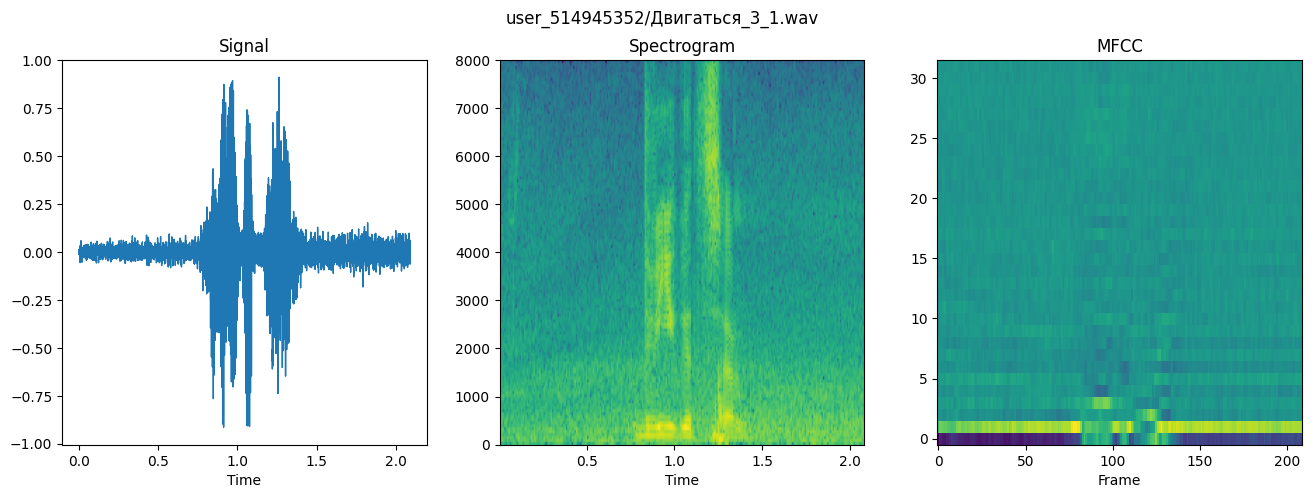

In [103]:
plot_waveform(signal, mfcc, sample_rate=16000, title=f'{xname}')
ipd.Audio(signal.cpu(), rate=16000)

In [104]:
input.shape

torch.Size([1, 1, 209, 32])

### Save to ONNX

In [87]:
dummy_input = torch.randn(input.shape)

# Экспорт модели в формат ONNX
torch.onnx.export(
    model, 
    dummy_input, 
    "model.onnx",           # имя выходного файла
    export_params=True,     # сохранить веса (параметры)
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input":  {2: "time_dim"},  # говорим, что ось с индексом 2 у входа - динамическая
        "output": {2: "time_dim"}   # то же самое (если выход тоже зависит от time_dim)
    },
)

================ Diagnostic Run torch.onnx.export version 2.0.1 ================
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================



In [90]:
input.shape, dummy_input.shape

(torch.Size([1, 1, 200, 32]), torch.Size([1, 1, 180, 32]))

In [105]:
import onnx
import onnxruntime

# Загружаем ONNX модель
onnx_model = onnx.load("model.onnx")
onnx.checker.check_model(onnx_model)  # Проверяем структуру и совместимость

# Пример выполнения через onnxruntime
session = onnxruntime.InferenceSession("model.onnx")
input_name = session.get_inputs()[0].name

In [127]:
%%timeit
result = session.run(None, {input_name: input.numpy()})

74.3 ms ± 11.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [120]:
result[0].shape, result

((1, 18),
 [array([[ 2.1532607 , -3.1847582 , -1.8480772 , -0.04882097, -3.9169888 ,
          11.305991  , -1.0486678 , -1.602831  , -4.008809  , -3.9975395 ,
           2.3851671 ,  3.2430198 , -1.2345308 , -4.0776777 ,  5.214545  ,
          -1.5891743 , -0.95365286, -1.4078476 ]], dtype=float32)])

In [112]:
def softmax(x):
    """Compute softmax values for each sets of scores in x."""
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=1) # only difference

In [113]:
final_labels[np.argmax(softmax(result[0]))]

'Вправо'

Ускорение в 2-3 раза